In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    SGDRegressor,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
df = pd.read_csv("yield_df.csv")

NameError: name 'pd' is not defined

In [ ]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [ ]:
df.shape

(28242, 8)

In [ ]:
df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [ ]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Area,0
Item,0
Year,0
hg/ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0


Remove the unnecessary index column:

In [ ]:
df = df.drop(columns=["Unnamed: 0"])

Verify:

In [ ]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


Histogram of Yield

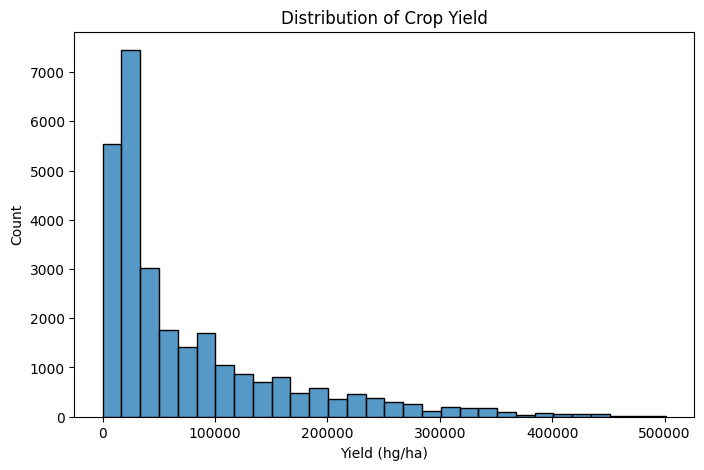

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["hg/ha_yield"], bins=30)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (hg/ha)")
plt.show()

Histogram of Rainfall

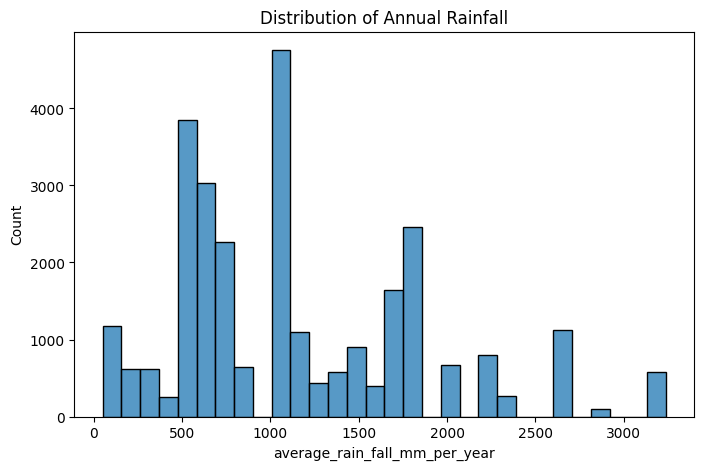

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["average_rain_fall_mm_per_year"], bins=30)
plt.title("Distribution of Annual Rainfall")
plt.show()

Histogram of Temperature

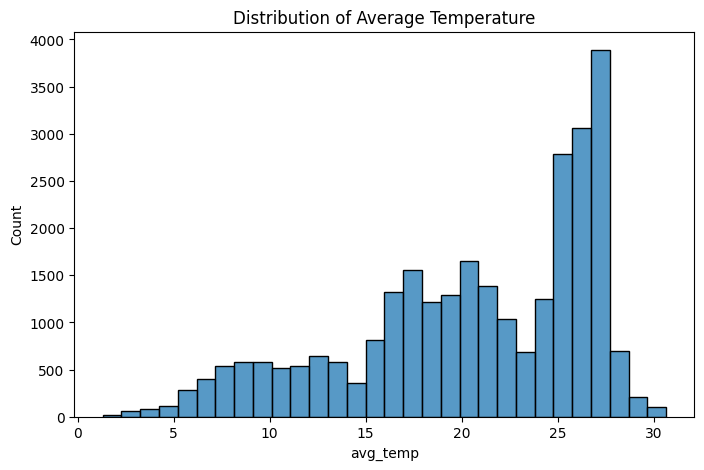

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["avg_temp"], bins=30)
plt.title("Distribution of Average Temperature")
plt.show()

Scatter Plot

In [ ]:
Scatter Plot

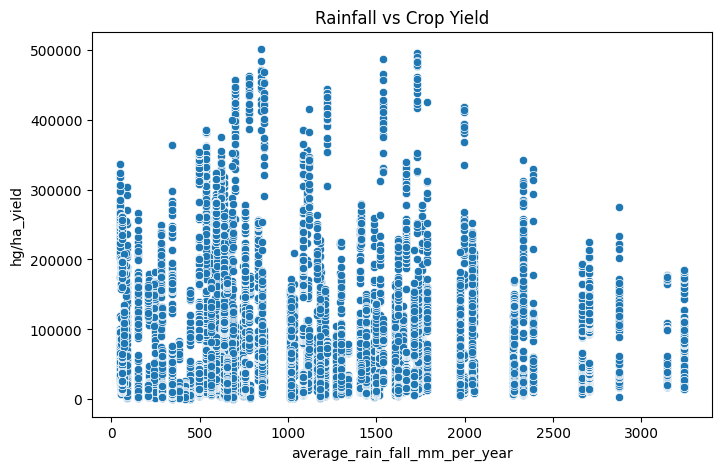

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["average_rain_fall_mm_per_year"],
    y=df["hg/ha_yield"]
)
plt.title("Rainfall vs Crop Yield")
plt.show()

Scatter Plot

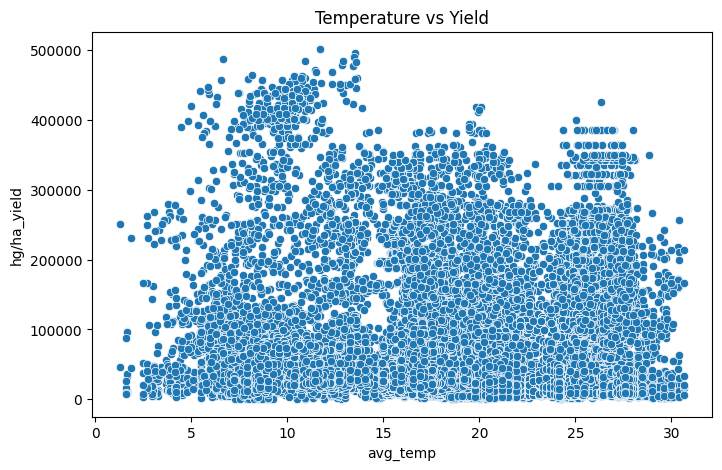

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["avg_temp"],
    y=df["hg/ha_yield"]
)
plt.title("Temperature vs Yield")
plt.show()

Scatter Plot

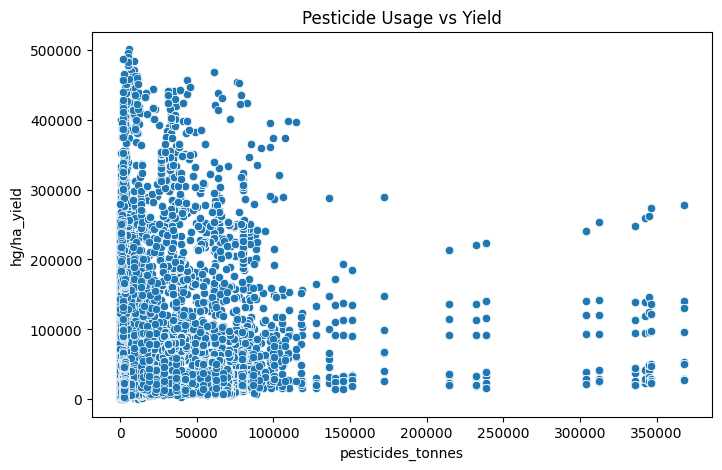

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["pesticides_tonnes"],
    y=df["hg/ha_yield"]
)
plt.title("Pesticide Usage vs Yield")
plt.show()

Correlation Heatmap

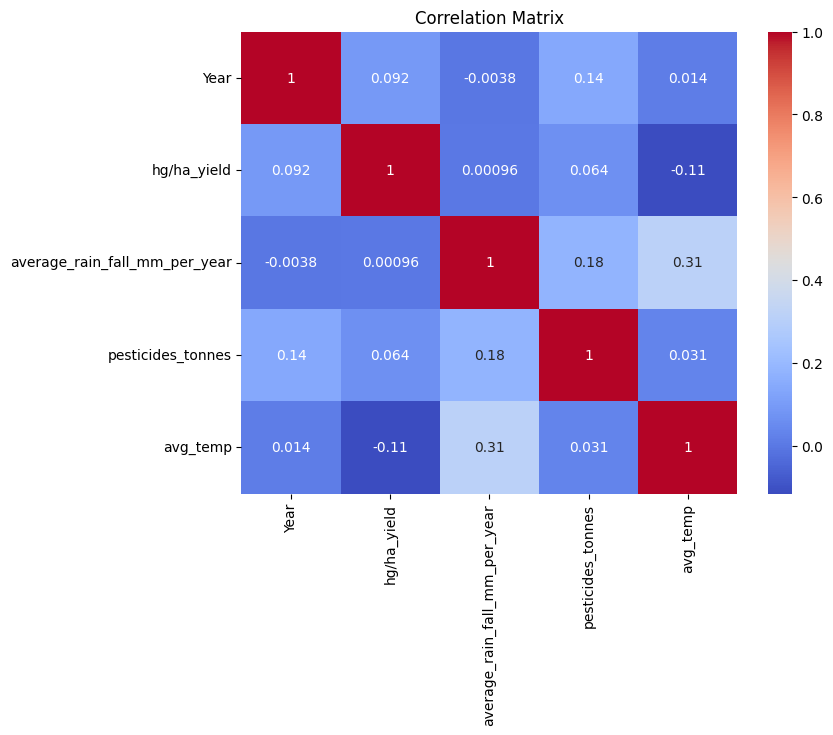

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

Separate features and target

In [ ]:
X = df.drop(columns=["hg/ha_yield"])
y = df["hg/ha_yield"]

Identify categorical and numerical columns

In [ ]:
categorical_features = ["Area", "Item"]

numerical_features = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

Create the preprocessing pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Split the Dataset

In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Build the Models

In [ ]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

sgd_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(
        max_iter=5000,
        learning_rate="adaptive",
        eta0=0.01,
        random_state=42
    ))
])

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.01))
])

Train the Models

In [ ]:
linear_pipeline.fit(X_train, y_train)

sgd_pipeline.fit(X_train, y_train)

ridge_pipeline.fit(X_train, y_train)

lasso_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year',
                                                   'average_rain_fall_mm_per_year',
                                                   'pesticides_tonnes',
                                                   'avg_temp']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Area', 'Item'])])),
                ('model', Lasso(alpha=0.01))])

Create an Evaluation Function

In [ ]:
def evaluate_model(model, model_name):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    }

Compare the Models

In [ ]:
results = []

results.append(
    evaluate_model(linear_pipeline, "Linear Regression")
)

results.append(
    evaluate_model(sgd_pipeline, "SGD Regressor")
)

results.append(
    evaluate_model(ridge_pipeline, "Ridge Regression")
)

results.append(
    evaluate_model(lasso_pipeline, "Lasso Regression")
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,29582.517700,1.776121e+09,42144.046449,0.755142
1,SGD Regressor,29519.167791,1.777835e+09,42164.385342,0.754905
2,Ridge Regression,29541.311144,1.775983e+09,42142.412403,0.755161
3,Lasso Regression,29582.281322,1.776118e+09,42144.016457,0.755142


Highlight the Best Model

In [ ]:
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df

,Model,MAE,MSE,RMSE,R² Score
2,Ridge Regression,29541.311144,1.775983e+09,42142.412403,0.755161
3,Lasso Regression,29582.281322,1.776118e+09,42144.016457,0.755142
0,Linear Regression,29582.517700,1.776121e+09,42144.046449,0.755142
1,SGD Regressor,29519.167791,1.777835e+09,42164.385342,0.754905


Save the Best Model Automatically

In [ ]:
models = {
    "Linear Regression": linear_pipeline,
    "SGD Regressor": sgd_pipeline,
    "Ridge Regression": ridge_pipeline,
    "Lasso Regression": lasso_pipeline
}

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print("Best model saved successfully!")

print("Selected model:", best_model_name)

Best model saved successfully!
Selected model: Ridge Regression


Test the Saved Model

In [ ]:
loaded_model = joblib.load("best_model.pkl")

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted Yield:", prediction[0])

print("Actual Yield:", y_test.iloc[0])

Predicted Yield: 83685.97754650236
Actual Yield: 69220


Train for Multiple Epochs

In [ ]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd

# Load the dataset (duplicated for cell independence)
df = pd.read_csv("/content/yield_df.csv")

# Define features (duplicated for cell independence)
categorical_features = ["Area", "Item"]

numerical_features = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

# Define preprocessor (duplicated for cell independence)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Define X and y (duplicated for cell independence)
X = df.drop(columns=["hg/ha_yield"])
y = df["hg/ha_yield"]

# Split the dataset into training and testing sets (duplicated for cell independence)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create a fresh SGD model
sgd_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(
        random_state=42,
        learning_rate="adaptive",
        eta0=0.01,
        warm_start=True # Removed max_iter=1 to allow more iterations per fit
    ))
])

epochs = 100

train_loss = []
test_loss = []

for epoch in range(epochs):

    sgd_model.fit(X_train, y_train)

    train_predictions = sgd_model.predict(X_train)

    test_predictions = sgd_model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_predictions)

    test_mse = mean_squared_error(y_test, test_predictions)

    train_loss.append(train_mse)

    test_loss.append(test_mse)

Plot Training Loss

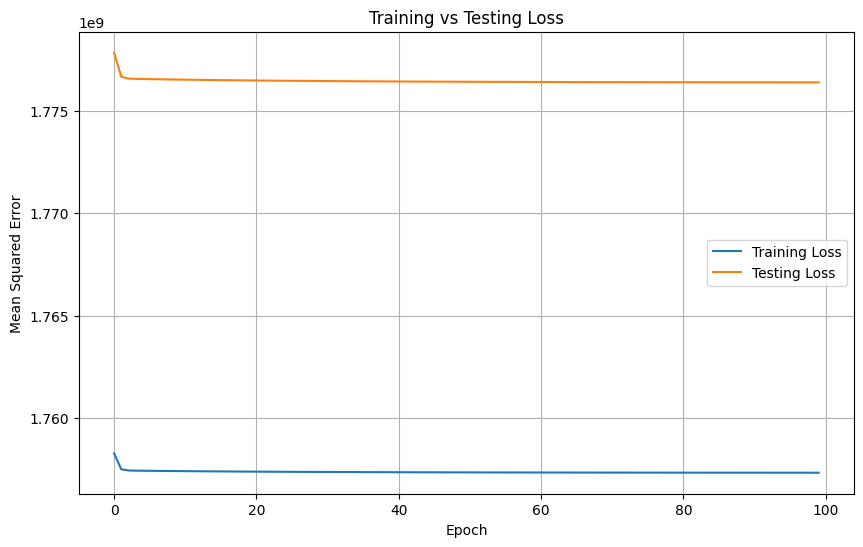

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(train_loss,label="Training Loss")

plt.plot(test_loss,label="Testing Loss")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.title("Training vs Testing Loss")

plt.legend()

plt.grid(True)

plt.show()

Actual vs Predicted

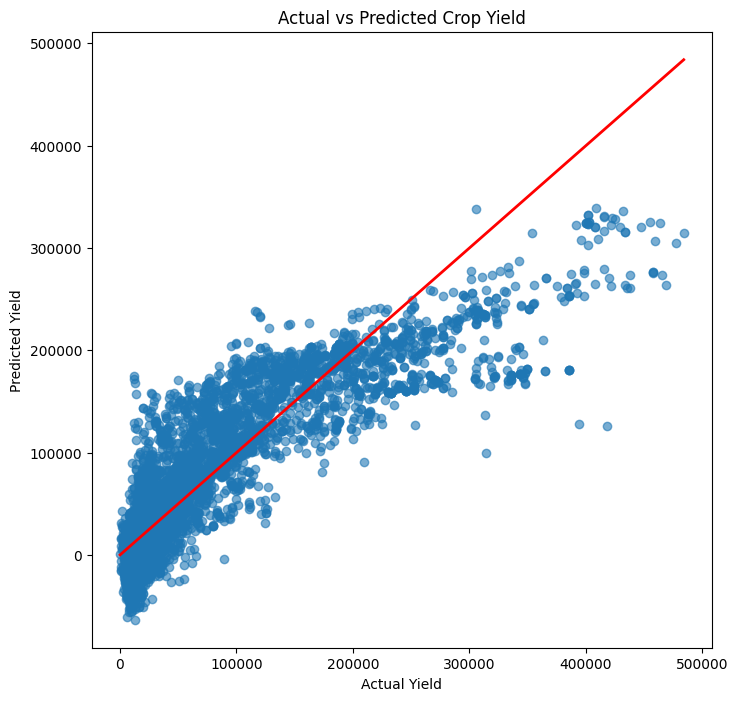

In [ ]:
import joblib
import matplotlib.pyplot as plt

# Load the best model
best_model = joblib.load("best_model.pkl")

best_predictions = best_model.predict(X_test)

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Crop Yield")

plt.show()

Before and After Regression

Before

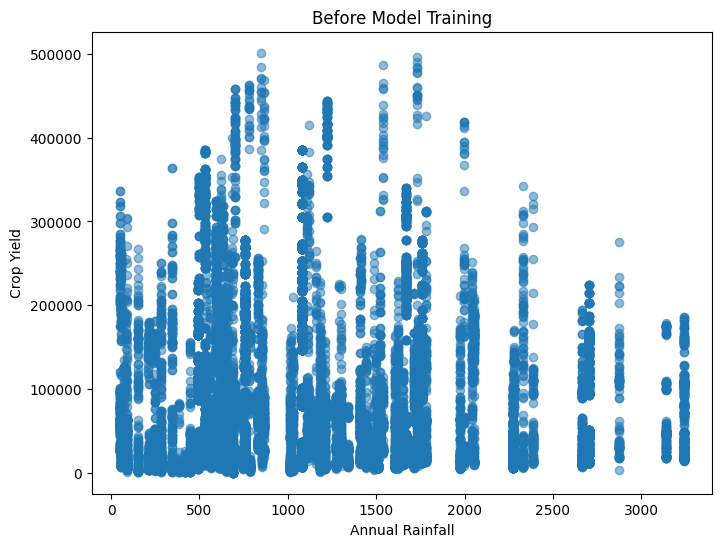

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["average_rain_fall_mm_per_year"],
    df["hg/ha_yield"],
    alpha=0.5
)

plt.xlabel("Annual Rainfall")

plt.ylabel("Crop Yield")

plt.title("Before Model Training")

plt.show()

After

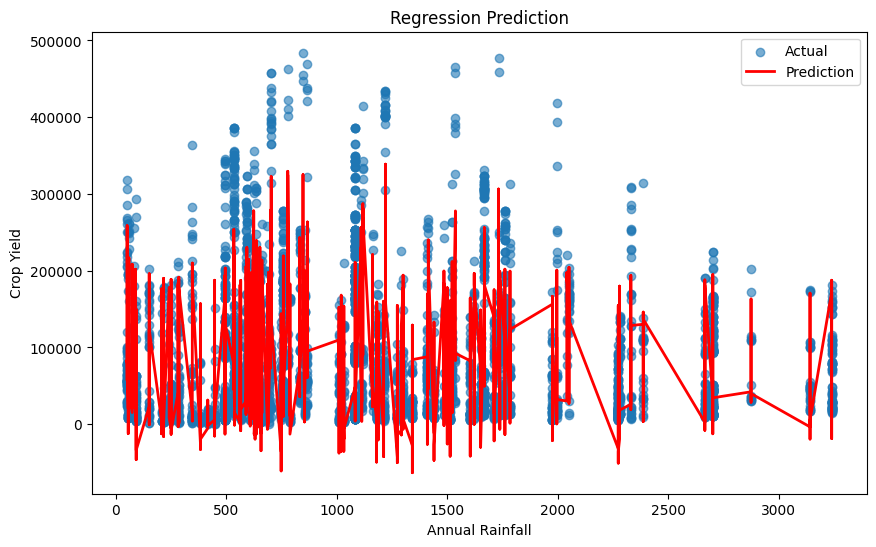

In [ ]:
plot_df = X_test.copy()

plot_df["Actual"] = y_test.values

plot_df["Prediction"] = best_predictions

plot_df = plot_df.sort_values(
    by="average_rain_fall_mm_per_year"
)

plt.figure(figsize=(10,6))

plt.scatter(
    plot_df["average_rain_fall_mm_per_year"],
    plot_df["Actual"],
    label="Actual",
    alpha=0.6
)

plt.plot(
    plot_df["average_rain_fall_mm_per_year"],
    plot_df["Prediction"],
    color="red",
    linewidth=2,
    label="Prediction"
)

plt.xlabel("Annual Rainfall")

plt.ylabel("Crop Yield")

plt.title("Regression Prediction")

plt.legend()

plt.show()

Prediction Function

In [ ]:
def predict_crop_yield(
    area,
    item,
    year,
    rainfall,
    pesticides,
    temperature
):

    sample = pd.DataFrame({

        "Area":[area],

        "Item":[item],

        "Year":[year],

        "average_rain_fall_mm_per_year":[rainfall],

        "pesticides_tonnes":[pesticides],

        "avg_temp":[temperature]

    })

    prediction = best_model.predict(sample)

    return prediction[0]

Example

In [ ]:
predict_crop_yield(
    area="Rwanda",
    item="Maize",
    year=2024,
    rainfall=1200,
    pesticides=45,
    temperature=22
)

np.float64(15568.451415206378)

Save the Final Model

In [ ]:
joblib.dump(best_model,"best_model.pkl")

print("Model saved successfully.")

Model saved successfully.


Final Conclusion

# Conclusion

Four regression algorithms were trained and evaluated for crop yield prediction.

The models were compared using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

The best-performing model achieved the highest prediction accuracy and was selected for deployment. The trained pipeline was saved and will be integrated into a FastAPI service to provide real-time crop yield predictions that can be accessed through a Flutter mobile application.